# Pubmat Checker — Metrics & Evaluation Notebook

This notebook measures how accurate and how fast the pubmat checker is. Testing set is manually labeled according to the guidelines, this serves to check whether the checker's audit (prediction) agrees with the label (actual).


## Imports

In [1]:
import cv2
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from ultralytics import YOLO

from checker import generate_report




## Configuration


In [2]:
TEST_SET_DIR = 'test_set/images/'           # folder containing test images
LABELS_FILE  = 'test_set/labels.json'
MODEL_PATH   = '../training/runs/detect/tuned_model_v2/weights/best.pt'

model = YOLO(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')

Model loaded: ../training/runs/detect/tuned_model_v2/weights/best.pt


## Test Set

### Test Set Labeling Guidelines

Each labels file is a JSON array where each entry corresponds to one test image.

Manually assign ground_truth values. For all checks: true = the pubmat passes based on guidelines, false = the pubmat fails

**Check Definitions**

- logo_nyc and logo_bp: true if logo is present AND correct, false if missing OR incorrect
- logo_sk or logo_yorp: only add them in if the post should have SK and/or YORP logos
- logo_order: true if correct, false if incorrect; (correct order must be NYC > (SK/YORP) > BP)
- watermark: true if all socmed handles are present as wm, false if not 
- pubmat_quality: true if image is sharp, not blurry, has good contrast, and resolution (at least 720px x 720px), false if blurry, low contrast, or low res
- readability: true if text is clear and readable, false if text too small, poor contrast with background, or font too illegible
- sgd: true if SGD appears in the document, false if not. (for advisory/resolution)
- spelling : true if no spelling errors found, false if misspelled words detected
- photo_quality: true if photo is at least 1080 x 1080px and in color, false if too small, too dark/bright, desaturated or gray

**Note**: spelling and photo_quality do not cause an overall fail result on their own. all other checks must pass to receive an overall PASS result.

**Example labels.json**

```json
[
  {
    "image": "pub_001.jpg",
    "post_type": "news",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "watermark":      false,
      "pubmat_quality": true,
      "readability":    true,
      "spelling":       true,
    },
    "notes": "No watermark"
  },
  {
    "image": "pub_003.jpg",
    "post_type": "photo",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "pubmat_quality": true,
      "readability":    true,
      "photo_quality":  false
    },
    "notes": "Photo is too dark."
  }
]
```

Add brief explanation for why the image fails in the "notes" section.

### Load and inspect the labels file

Read labels and counts instances

In [3]:
with open(LABELS_FILE) as f:
    test_set = json.load(f)

print(f'Test set loaded: {len(test_set)} images\n')
print('Post type breakdown:')
type_counts = Counter(s['post_type'] for s in test_set)
for ptype, count in sorted(type_counts.items()):
    print(f'  {ptype:<14} {count} images')

Test set loaded: 114 images

Post type breakdown:
  advisory       3 images
  holiday        17 images
  news           14 images
  opportunity    3 images
  other          46 images
  photo          26 images
  quote          4 images
  resolution     1 images



## Prediction Extractor

This function translates the nested audit output into the same flat key format as ground truth so that comparisons work directly.

Key mappings:
- `audit['logos']['details']['logos']` list → `predicted['logo_nyc']`, `predicted['logo_bp']`, etc.
- `audit['logo_order']['pass']` → `predicted['logo_order']`
- `audit['watermark']['pass']` → `predicted['watermark']`
- `audit['readability']['pass']` → `predicted['readability']`
- `audit['spelling']['pass']` → `predicted['spelling']`
- `audit['sgd']['pass']` → `predicted['sgd']`
- `audit['pubmat_quality']['pass']` → `predicted['pubmat_quality']`
- `audit['photo_quality']['pass']` → `predicted['photo_quality']`


In [4]:
def extract_predictions(audit: dict) -> dict:
    """
    Flatten the audit dict into the same key format as ground_truth.
    Returns a dict of {check_name: bool}.
    """
    preds = {}

    # Logo compliance — one key per logo that was checked
    # audit['logos']['details']['logos'] is a list of per-logo dicts
    for logo_entry in audit.get('logos', {}).get('details', {}).get('logos', []):
        key = f"logo_{logo_entry['logo'].lower()}"
        preds[key] = logo_entry['pass']

    # Checks that always run
    if 'logo_order' in audit:
        preds['logo_order'] = audit['logo_order']['pass']
    if 'pubmat_quality' in audit:
        preds['pubmat_quality'] = audit['pubmat_quality']['pass']

    # Conditional checks — present only when applicable to the post type
    for key in ('readability', 'watermark', 'sgd', 'spelling', 'photo_quality'):
        if key in audit:
            preds[key] = audit[key]['pass']

    return preds

## Run the Full Test Set

This is the main processing loop. For every image in the test set it:
1. Reads the image from disk
2. Calls `generate_report()` which runs YOLO + OCR + all checks internally
3. Records how long the whole call took
4. Extracts predictions using `extract_predictions()`
5. Stores ground truth, predictions, and timing together


In [5]:
results = []
errors  = []

for sample in test_set:
    img_path = os.path.join(TEST_SET_DIR, sample['image'])

    if not os.path.exists(img_path):
        errors.append({'image': sample['image'], 'error': 'File does not exist'})
        continue

    image = cv2.imread(img_path)
    if image is None:
        errors.append({'image': sample['image'], 'error': 'Failed to load image (corrupted or unsupported)'})
        continue

    try:
        t_start = time.perf_counter()

        audit, _ = generate_report(
            image,
            logo_model=model,
            post_type=sample['post_type'],
            collaborators=sample.get('collaborators', []),
        )

        elapsed = time.perf_counter() - t_start

        results.append({
            'image':        sample['image'],
            'post_type':    sample['post_type'],
            'ground_truth': sample['ground_truth'],
            'predicted':    extract_predictions(audit),
            'audit_raw':    audit,
            'elapsed_s':    round(elapsed, 3),
            'notes':        sample.get('notes', ''),
        })

    except Exception as e:
        import traceback
        errors.append({'image': sample['image'], 'error': str(e), 'traceback': traceback.format_exc()})

print(f'Processed : {len(results)} images')
print(f'Errors    : {len(errors)}')
if errors:
    for e in errors:
        print(f'  {e["image"]}: {e["error"]}')



0: 800x640 1 NYC_Correct, 1 BP_Incorrect, 1 SK_Incorrect, 1 YORP_Correct, 60.0ms
Speed: 18.5ms preprocess, 60.0ms inference, 9.4ms postprocess per image at shape (1, 3, 800, 640)

0: 544x800 1 NYC_Correct, 1 BP_Correct, 60.7ms
Speed: 3.1ms preprocess, 60.7ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 800)

0: 800x640 1 NYC_Correct, 1 SK_Correct, 1 YORP_Correct, 131.4ms
Speed: 6.2ms preprocess, 131.4ms inference, 1.7ms postprocess per image at shape (1, 3, 800, 640)

0: 800x640 2 NYC_Corrects, 2 BP_Corrects, 201.6ms
Speed: 8.3ms preprocess, 201.6ms inference, 1.8ms postprocess per image at shape (1, 3, 800, 640)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 57.0ms
Speed: 130.5ms preprocess, 57.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 12.6ms
Speed: 3.1ms preprocess, 12.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 800)

0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 16.6ms
Speed: 28


## Metrics

True Positive (TP): Checker correctly said PASS. Image genuinely passes. \
True Negative (TN): Checker correctly said FAIL. Image genuinely fails. \
False Positive (FP): Checker said PASS but image actually fails. The checker missed a real problem. \
False Negative (FN): Checker said FAIL but image actually passes. The checker flagged something that is fine.


**Precision = TP / (TP + FP)**

**Recall = TP / (TP + FN)**

**F1 Score = 2 * (Precision * Recall) / (Precision + Recall)**



In [6]:
# Derive per-check severity level from POST_TYPE_RULES
# A check is 'warning' if it appears as warning in ANY post type rule.
WARNING_CHECKS = {'spelling', 'photo_quality'}  # checks with level='warning' in checker.py

# Group y_true and y_pred by check name across all images
by_check = defaultdict(lambda: {'y_true': [], 'y_pred': [], 'images': []})

for r in results:
    for check, true_val in r['ground_truth'].items():
        if check in r['predicted']:
            by_check[check]['y_true'].append(int(true_val))
            by_check[check]['y_pred'].append(int(r['predicted'][check]))
            by_check[check]['images'].append(r['image'])

rows = []
for check, data in sorted(by_check.items()):
    yt, yp = data['y_true'], data['y_pred']
    n   = len(yt)
    p   = precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    f1  = f1_score(yt, yp, zero_division=0)
    acc = sum(t == p_ for t, p_ in zip(yt, yp)) / n
    level = 'warning' if check in WARNING_CHECKS else 'error'
    rows.append({'check': check, 'level': level, 'n': n,
                 'precision': p, 'recall': rec, 'f1': f1, 'accuracy': acc})

df_metrics = pd.DataFrame(rows).set_index('check').sort_values('f1')

display(df_metrics.style
    .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}', 'accuracy': '{:.3f}'})
    .background_gradient(subset=['precision', 'recall', 'f1', 'accuracy'], cmap='RdYlGn', vmin=0, vmax=1)
)


,level,n,precision,recall,f1,accuracy
check,,,,,,
spelling,warning,80,1.000,0.087,0.160,0.212
logo_sk,error,17,0.846,0.917,0.880,0.824
logo_yorp,error,16,0.857,0.923,0.889,0.812
photo_quality,warning,26,0.850,1.000,0.919,0.885
logo_order,error,114,0.978,0.929,0.953,0.921
pubmat_quality,error,114,1.000,0.918,0.957,0.921
logo_bp,error,114,0.971,0.990,0.980,0.965
logo_nyc,error,114,0.990,0.971,0.980,0.965
readability,error,84,0.976,1.000,0.988,0.976


### Bar Chart — Precision vs Recall vs F1 per Check

The same numbers visualised as grouped bars. The red dashed line at 0.90 is a rough target — any check below it is worth investigating. Checks where precision and recall are far apart (one bar much taller than the other) indicate the check is biased in one direction.

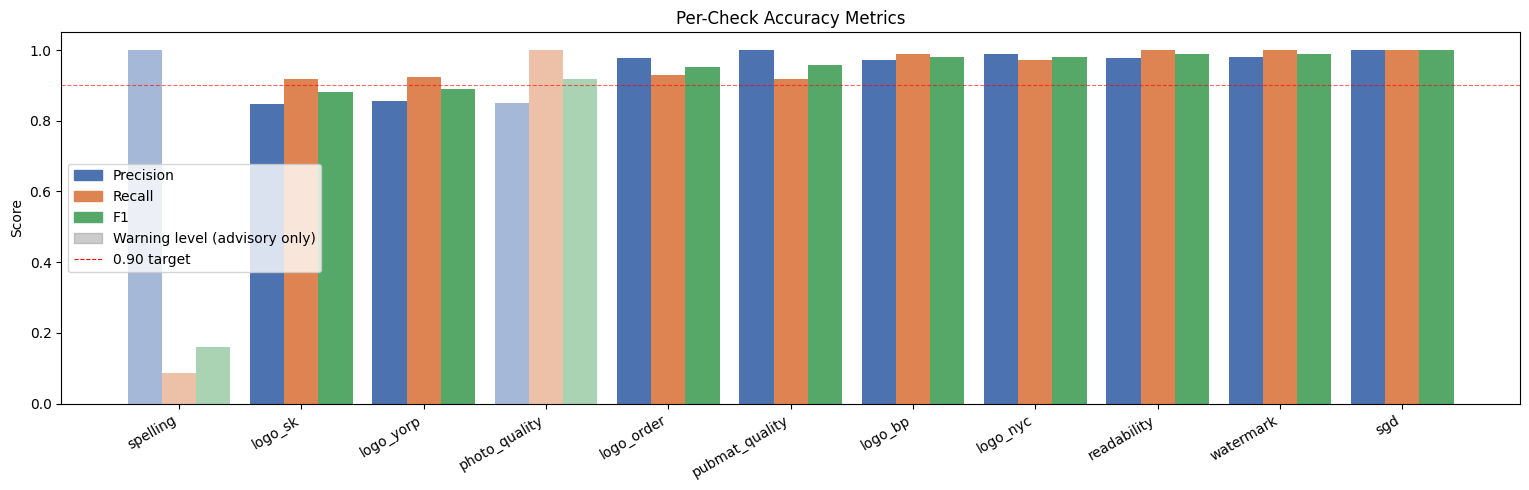

In [7]:
checks = df_metrics.index.tolist()
x = np.arange(len(checks))
w = 0.28

fig, ax = plt.subplots(figsize=(max(12, len(checks) * 1.4), 5))

for i, (check, row) in enumerate(df_metrics.iterrows()):
    alpha = 0.5 if row['level'] == 'warning' else 1.0
    ax.bar(i - w, row['precision'], w, color='#4C72B0', alpha=alpha)
    ax.bar(i,     row['recall'],    w, color='#DD8452', alpha=alpha)
    ax.bar(i + w, row['f1'],        w, color='#55A868', alpha=alpha)

ax.set_xticks(x)
ax.set_xticklabels(checks, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='0.90 target')
ax.set_title('Per-Check Accuracy Metrics')
ax.set_ylabel('Score')

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Precision'),
    mpatches.Patch(color='#DD8452', label='Recall'),
    mpatches.Patch(color='#55A868', label='F1'),
    mpatches.Patch(color='grey', alpha=0.4, label='Warning level (advisory only)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=0.8, label='0.90 target'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()


## Confusion Matrices

A confusion matrix shows the four outcome types (TP, TN, FP, FN) as a 2×2 grid for each check.


|                |Predicted FAIL |   Predicted PASS |
| -- | -- | ---|
|Actual FAIL     |  TN            |   FP |
|Actual PASS     |  FN           |    TP |


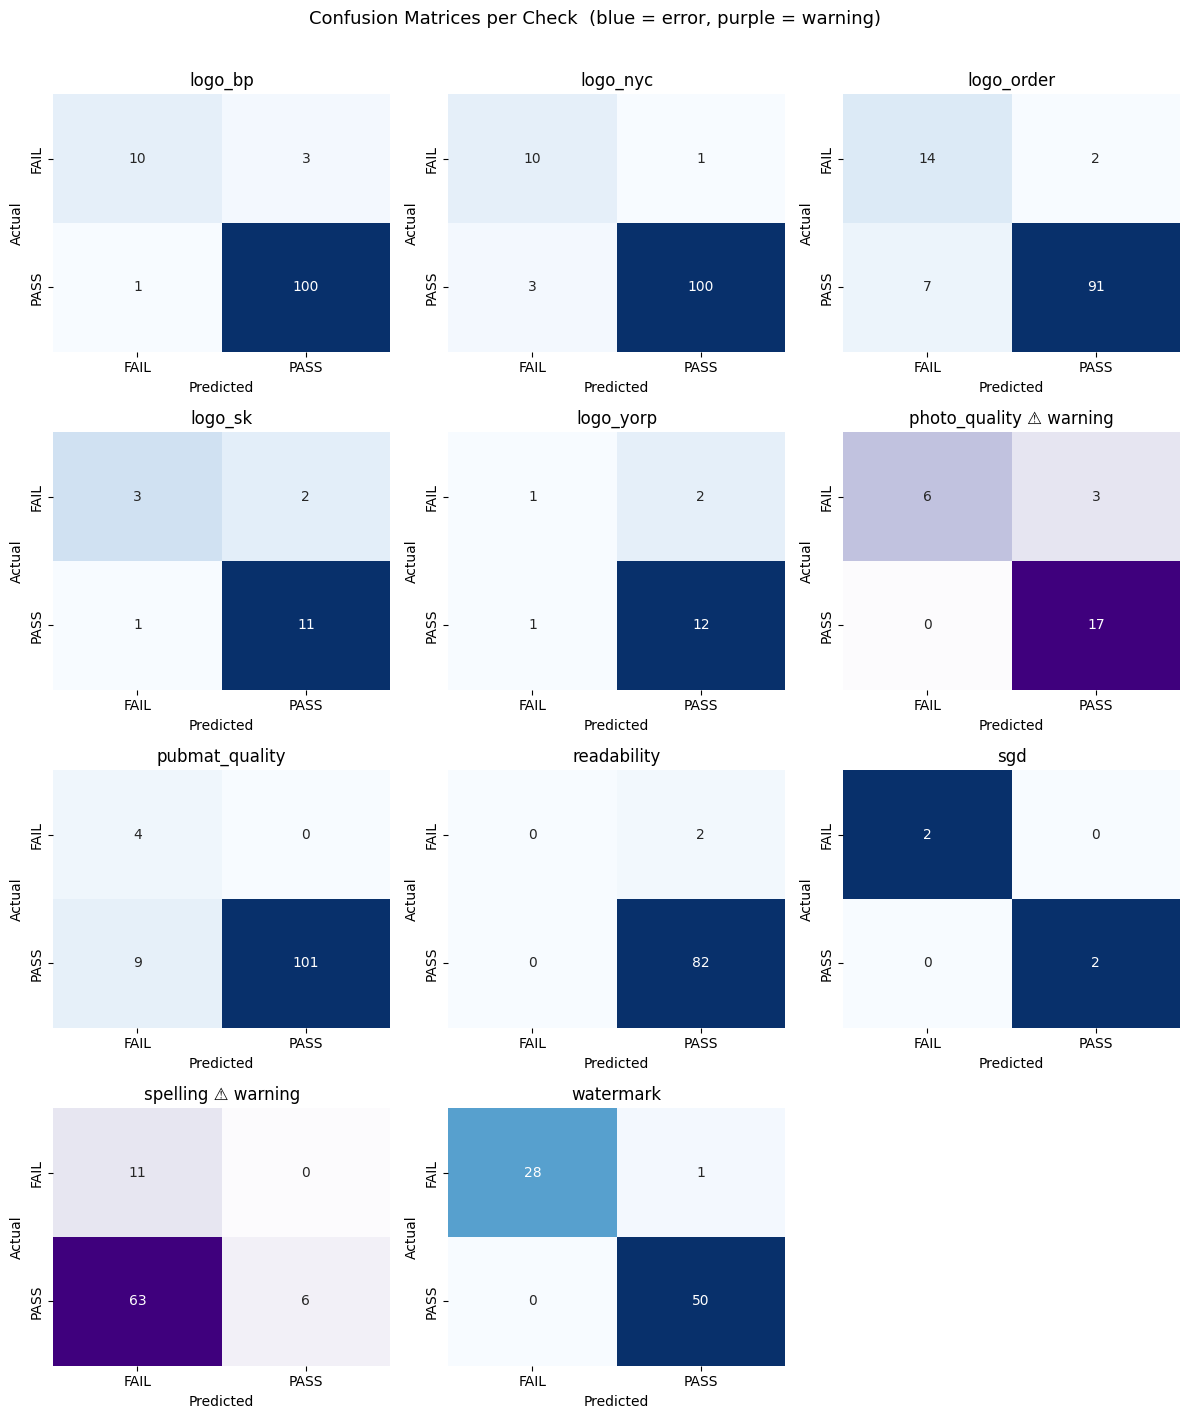

In [8]:
n_checks  = len(by_check)
cols_grid = 3
rows_grid = (n_checks + cols_grid - 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(cols_grid * 4, rows_grid * 3.5))
axes = axes.flatten()

for i, (check, data) in enumerate(sorted(by_check.items())):
    level = 'warning' if check in WARNING_CHECKS else 'error'
    cmap  = 'Purples' if level == 'warning' else 'Blues'
    cm = confusion_matrix(data['y_true'], data['y_pred'], labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[i],
        cmap=cmap, cbar=False,
        xticklabels=['FAIL', 'PASS'],
        yticklabels=['FAIL', 'PASS'],
    )
    title_suffix = ' ⚠ warning' if level == 'warning' else ''
    axes[i].set_title(f'{check}{title_suffix}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices per Check  (blue = error, purple = warning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



## Full Classification Reports

sklearn's `classification_report` prints a detailed breakdown per check including per-class precision, recall, and F1 for both the FAIL class and the PASS class, plus support (how many samples of each class exist).

- The **FAIL class** metrics tell you: when the checker flags a failure, how accurate is that flag?
- The **PASS class** metrics tell you: when the checker clears something, how confident should you be?
- Checks marked `⚠ warning` are advisory — they do **not** cause an overall FAIL.



In [9]:
for check, data in sorted(by_check.items()):
    level_tag = ' [warning]' if check in WARNING_CHECKS else ' [error]'
    print(f'\n══ {check}{level_tag} (n={len(data["y_true"])}) ══')
    print(classification_report(
        data['y_true'], data['y_pred'],
        labels=[0, 1],
        target_names=['FAIL', 'PASS'],
        zero_division=0,
    ))



══ logo_bp [error] (n=114) ══
              precision    recall  f1-score   support

        FAIL       0.91      0.77      0.83        13
        PASS       0.97      0.99      0.98       101

    accuracy                           0.96       114
   macro avg       0.94      0.88      0.91       114
weighted avg       0.96      0.96      0.96       114


══ logo_nyc [error] (n=114) ══
              precision    recall  f1-score   support

        FAIL       0.77      0.91      0.83        11
        PASS       0.99      0.97      0.98       103

    accuracy                           0.96       114
   macro avg       0.88      0.94      0.91       114
weighted avg       0.97      0.96      0.97       114


══ logo_order [error] (n=114) ══
              precision    recall  f1-score   support

        FAIL       0.67      0.88      0.76        16
        PASS       0.98      0.93      0.95        98

    accuracy                           0.92       114
   macro avg       0.82      0.


## Overall Pass/Fail Accuracy

The per-check metrics above tell you how each individual check performs. But in practice a reviewer sees one overall PASS or FAIL verdict per image, not per check.

This section measures whether the overall verdict is correct.

**How overall ground truth is calculated:**
An image's overall ground truth is `PASS` only if every single check in its ground_truth is `true`. If any one check is `false`, the overall ground truth is `FAIL`. This mirrors exactly how `generate_report()` calculates `audit['overall']`.

**Why overall accuracy is usually lower than individual check accuracy:**
Each check has its own error rate. The overall verdict is wrong if any check gets it wrong. So if you have 6 checks each at 95% accuracy, the chance of the overall verdict being correct is roughly 0.95^6 ≈ 0.74 — 74%. This is normal and expected.

Overall Pass/Fail
              precision    recall  f1-score   support

        FAIL       0.85      0.92      0.88        37
        PASS       0.96      0.92      0.94        77

    accuracy                           0.92       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.92      0.92       114



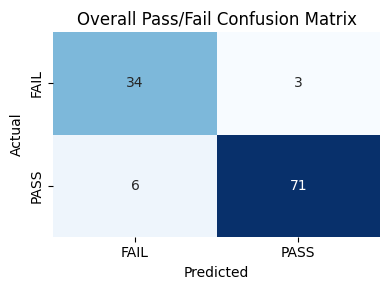

In [10]:
overall_true, overall_pred = [], []

for r in results:
    # Ground truth: PASS only if all error-level checks pass
    gt_overall = all(
        v for k, v in r['ground_truth'].items()
        if k not in WARNING_CHECKS
    )
    # Predicted: mirrors audit['overall'] — warnings never cause FAIL
    pred_overall = all(
        r['predicted'].get(k, True)
        for k in r['ground_truth'].keys()
        if k not in WARNING_CHECKS        
        and k in r['predicted']           # only compare checks that were actually run
    )
    overall_true.append(int(gt_overall))
    overall_pred.append(int(pred_overall))

print('Overall Pass/Fail')
print(classification_report(
    overall_true, overall_pred,
    target_names=['FAIL', 'PASS'],
    zero_division=0,
))

cm_overall = confusion_matrix(overall_true, overall_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_overall, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['FAIL', 'PASS'], yticklabels=['FAIL', 'PASS'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Overall Pass/Fail Confusion Matrix')
plt.tight_layout()
plt.show()

## Pipeline Timing

These cells measure how long `generate_report()` takes per image (YOLO detection is excluded — it runs before the timer starts).

**What the timing statistics mean:**
- **Mean** — the average time across all images. Use this for planning throughput.
- **Median** — the middle value. More robust than mean if a few slow images are skewing the average.
- **P95** — 95th percentile. 95% of images complete within this time. This is the number to use for worst-case planning since it ignores the extreme outliers.
- **Max** — the single slowest image. Usually an outlier caused by a very high-res image or a particularly complex OCR pass.

The histogram shows the shape of the distribution — you want a tight cluster near the left. A long tail to the right means some images are significantly slower and worth investigating.

The boxplot by post type shows whether certain post types are consistently slower. Photo and advisory posts tend to be slower because photo_quality and SGD add extra computation.

In [11]:
times = [r['elapsed_s'] for r in results]

print(f'Mean   : {np.mean(times):.3f}s')
print(f'Median : {np.median(times):.3f}s')
print(f'P95    : {np.percentile(times, 95):.3f}s')
print(f'Max    : {np.max(times):.3f}s')
print(f'Min    : {np.min(times):.3f}s')

Mean   : 8.184s
Median : 4.963s
P95    : 24.405s
Max    : 35.682s
Min    : 3.023s


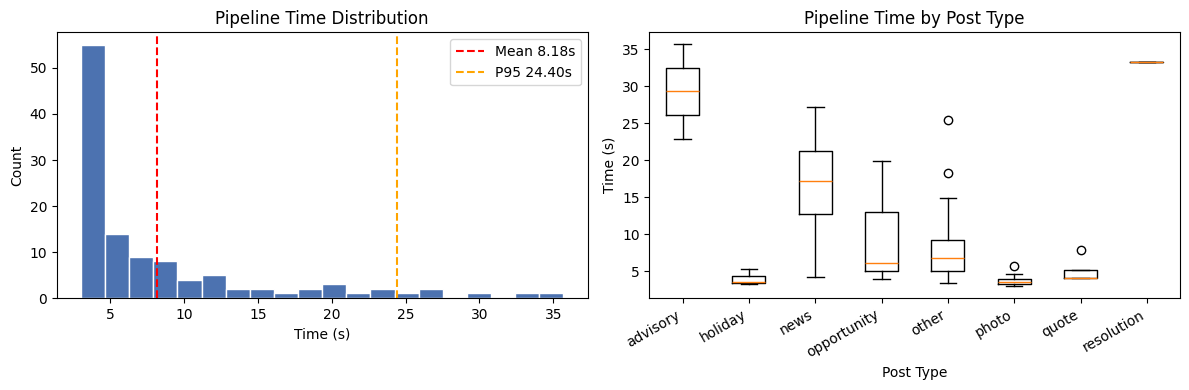

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(times, bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(np.mean(times),           color='red',    linestyle='--', label=f'Mean {np.mean(times):.2f}s')
axes[0].axvline(np.percentile(times, 95), color='orange', linestyle='--', label=f'P95 {np.percentile(times, 95):.2f}s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pipeline Time Distribution')
axes[0].legend()

type_times = defaultdict(list)
for r in results:
    type_times[r['post_type']].append(r['elapsed_s'])

labels_t = sorted(type_times.keys())
data_t   = [type_times[k] for k in labels_t]
axes[1].boxplot(data_t, tick_labels=labels_t)
axes[1].set_xlabel('Post Type')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Pipeline Time by Post Type')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()



##  Error Analysis

The metrics tell you how often the checker is wrong. This section tells you exactly which images it got wrong and why.

**Disagreement types:**
- `FP` (False Positive): checker said PASS, human said FAIL — checker **missed a real problem**
- `FN` (False Negative): checker said FAIL, human said PASS — checker raised a **false alarm**

The breakdown table groups disagreements by check and error type. The image viewer at the bottom lets you inspect the actual failing images — change `check_filter` and `error_type_filter` to drill into specific checks.

In [19]:
disagreements = []

for r in results:
    for check, true_val in r['ground_truth'].items():
        if true_val is None:          
            continue
        if check not in r['predicted']:
            continue
        pred_val = r['predicted'][check]
        if pred_val != true_val:
            error_type = 'FP' if pred_val and not true_val else 'FN'
            level = 'warning' if check in WARNING_CHECKS else 'error'
            disagreements.append({
                'image':      r['image'],
                'post_type':  r['post_type'],
                'check':      check,
                'level':      level,
                'error_type': error_type,
                'truth':      true_val,
                'predicted':  pred_val,
                'notes':      r['notes'],
            })

df_errors = pd.DataFrame(disagreements)
print(f'Total disagreements: {len(df_errors)}')

if not df_errors.empty:
    print('\nBreakdown by check and error type (FP = missed problem, FN = false alarm):')
    pivot = df_errors.groupby(['check', 'level', 'error_type']).size().unstack(fill_value=0)
    print(pivot.to_string())


Total disagreements: 101

Breakdown by check and error type (FP = missed problem, FN = false alarm):
error_type              FN  FP
check          level          
logo_bp        error     1   3
logo_nyc       error     3   1
logo_order     error     7   2
logo_sk        error     1   2
logo_yorp      error     1   2
photo_quality  warning   0   3
pubmat_quality error     9   0
readability    error     0   2
spelling       warning  63   0
watermark      error     0   1


In [23]:
if not df_errors.empty:
    display(df_errors.sort_values(['level', 'check', 'error_type']))


,image,post_type,check,level,error_type,truth,predicted,notes
31,test_44.jpg,resolution,logo_bp,error,FN,True,False,no sgd
8,test_15.png,other,logo_bp,error,FP,False,True,Watermark Missing
12,test_16.png,other,logo_bp,error,FP,False,True,
58,test_72.png,other,logo_bp,error,FP,False,True,Watermark missing. Incorrect SK BP YORP logos
19,test_30.jpg,other,logo_nyc,error,FN,True,False,"BP incorrect, Logo order invalid. Watermark mi..."
...,...,...,...,...,...,...,...,...
92,test_104.jpg,other,spelling,warning,FN,True,False,
94,test_106.jpg,holiday,spelling,warning,FN,True,False,No watermark
95,test_107.jpg,opportunity,spelling,warning,FN,True,False,image blurry
96,test_108.jpg,holiday,spelling,warning,FN,True,False,


In [24]:
if not df_errors.empty:
    display(df_errors[df_errors['check'] == 'logo_nyc'])


,image,post_type,check,level,error_type,truth,predicted,notes
19,test_30.jpg,other,logo_nyc,error,FN,True,False,"BP incorrect, Logo order invalid. Watermark mi..."
30,test_44.jpg,resolution,logo_nyc,error,FN,True,False,no sgd
73,test_85.jpg,other,logo_nyc,error,FP,False,True,Logo order wrong. Watermark missing.
79,test_88.jpg,holiday,logo_nyc,error,FN,True,False,"Misspelled Independence, watermark missing."


In [16]:
# Display actual images where errors occurred

check_filter      = 'watermark'   # any check name from the table above
error_type_filter = 'FN'        # 'FP' (missed problem) or 'FN' (false alarm)

subset = df_errors[
    (df_errors['check'] == check_filter) &
    (df_errors['error_type'] == error_type_filter)
]

if subset.empty:
    print(f'No {error_type_filter} errors for "{check_filter}"')
else:
    n = min(len(subset), 6)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.head(n).iterrows()):
        img = cv2.imread(os.path.join(TEST_SET_DIR, row['image']))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['image']}\n{row['notes']}", fontsize=8, wrap=True)
        ax.axis('off')
    plt.suptitle(f'{check_filter} — {error_type_filter} errors', fontsize=12)
    plt.tight_layout()
    plt.show()


No FN errors for "watermark"
